# Level 2：X-Learner

## 為什麼 X-Learner 比 T-Learner 更好？

T-Learner 的問題：Contact=1 只有 10K 樣本，M1 嚴重過擬合（Holdout AUC = 0.59）。

X-Learner 解法：**用 M0（90K 樣本，穩定）去幫 M1 的訓練打底**。

### 演算法步驟

**Step 1：訓練基礎模型（與 T-Learner 相同）**
- M0 在 Contact=0 群（89K）訓練 → 估計「不聯繫時的捐款率」
- M1 在 Contact=1 群（10K）訓練 → 估計「聯繫後的捐款率」

**Step 2：計算偽目標（Pseudo Outcome）**
- 對 Contact=1 的人：`D1 = 實際結果 - M0(x)` → 「聯繫比預期多貢獻了多少」
- 對 Contact=0 的人：`D0 = M1(x) - 實際結果` → 「如果聯繫他，比現在多多少」

**Step 3：訓練 CATE 估計器**
- τ1 在 Contact=1 群訓練，target = D1
- τ0 在 Contact=0 群訓練，target = D0

**Step 4：用 Propensity Score 加權合併**
- 訓練 g(x) = P(Contact=1 | x)（傾向評分）
- `CATE = g(x) × τ0(x) + (1 - g(x)) × τ1(x)`

直觀解釋：`g(x)` 高 → 這個人本來就容易被聯繫到，用 τ0（control 群估計）更可信；`g(x)` 低 → 用 τ1（treatment 群估計）更可信。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import roc_auc_score, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 12

# 使用 Optuna GBM 最佳超參數
BEST_PARAMS = {
    'n_estimators': 375, 'max_depth': 6, 'learning_rate': 0.0129,
    'subsample': 0.604, 'min_samples_leaf': 45, 'random_state': 42
}
print('X-Learner 準備完成')
print(f'使用 GBM 超參數（來自 Optuna 搜尋結果）: {BEST_PARAMS}')

X-Learner 準備完成
使用 GBM 超參數（來自 Optuna 搜尋結果）: {'n_estimators': 375, 'max_depth': 6, 'learning_rate': 0.0129, 'subsample': 0.604, 'min_samples_leaf': 45, 'random_state': 42}


In [2]:
# ============================================================
# 1. 載入資料
# ============================================================

def load_and_clean(path):
    df = pd.read_csv(path, low_memory=False, encoding='utf-8-sig')
    df.columns = df.columns.str.strip().str.strip('"')
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].str.strip().str.strip('"')
    num_cols = ['Contact', 'GaveThisYear', 'AmtThisYear', 'Woman', 'Age', 'Salary',
                'SeniorList', 'NbActivities', 'Referrals', 'Recency', 'Frequency',
                'Seniority', 'TotalGift', 'MinGift', 'MaxGift', 'GaveLastYear', 'AmtLastYear']
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

DROP_COLS = ['ID', 'LastName', 'FirstName', 'Contact', 'GaveThisYear', 'AmtThisYear']
CAT_COLS  = ['Education', 'City']

def preprocess(df, feature_cols=None):
    out = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
    out = pd.get_dummies(out, columns=[c for c in CAT_COLS if c in out.columns], drop_first=True)
    if feature_cols is not None:
        for col in feature_cols:
            if col not in out.columns:
                out[col] = 0
        out = out[feature_cols]
    return out

train = load_and_clean('data/表格_FUNDRAISE_R2_TRAIN.csv')
train = train.dropna(subset=['Contact', 'GaveThisYear', 'AmtThisYear']).reset_index(drop=True)

# 先切 val（必須在分 Contact 群之前）
train_split, val_split = train_test_split(train, test_size=0.2, random_state=42,
                                           stratify=train['GaveThisYear'].astype(int))
train_split = train_split.reset_index(drop=True)
val_split   = val_split.reset_index(drop=True)

feature_cols = preprocess(train).columns.tolist()

# 切 Contact 群（從 train_split 切，val 完全隔離）
tr0 = train_split[train_split['Contact'] == 0].reset_index(drop=True)
tr1 = train_split[train_split['Contact'] == 1].reset_index(drop=True)

X0    = preprocess(tr0, feature_cols); Y0 = tr0['GaveThisYear'].astype(int).values
X1    = preprocess(tr1, feature_cols); Y1 = tr1['GaveThisYear'].astype(int).values
X_val = preprocess(val_split, feature_cols)
Y_val = val_split['GaveThisYear'].astype(int).values
Y_amt_val = val_split['AmtThisYear'].values

print(f'train0: {len(X0):,}  train1: {len(X1):,}  val: {len(X_val):,}')

train0: 71,872  train1: 8,128  val: 20,000


In [3]:
# ============================================================
# 2. Step 1：訓練基礎模型 M0、M1
# ============================================================

M0 = GradientBoostingClassifier(**BEST_PARAMS)
M0.fit(X0, Y0)
auc_M0 = roc_auc_score(Y_val, M0.predict_proba(X_val)[:, 1])
print(f'M0 Holdout AUC: {auc_M0:.4f}  (T-Learner 時: 0.6619)')

M1 = GradientBoostingClassifier(**BEST_PARAMS)
M1.fit(X1, Y1)
auc_M1 = roc_auc_score(Y_val, M1.predict_proba(X_val)[:, 1])
print(f'M1 Holdout AUC: {auc_M1:.4f}  (T-Learner 時: 0.5914)')

M0 Holdout AUC: 0.6615  (T-Learner 時: 0.6619)
M1 Holdout AUC: 0.5901  (T-Learner 時: 0.5914)


D1 (Contact=1 群) 統計:
  mean=0.2166, std=0.4836
  正值(實際>預期): 3,230, 負值(Sleeping Dog): 4,898

D0 (Contact=0 群) 統計:
  mean=0.2183, std=0.4235
  正值(聯繫有效): 58,850, 負值: 13,022


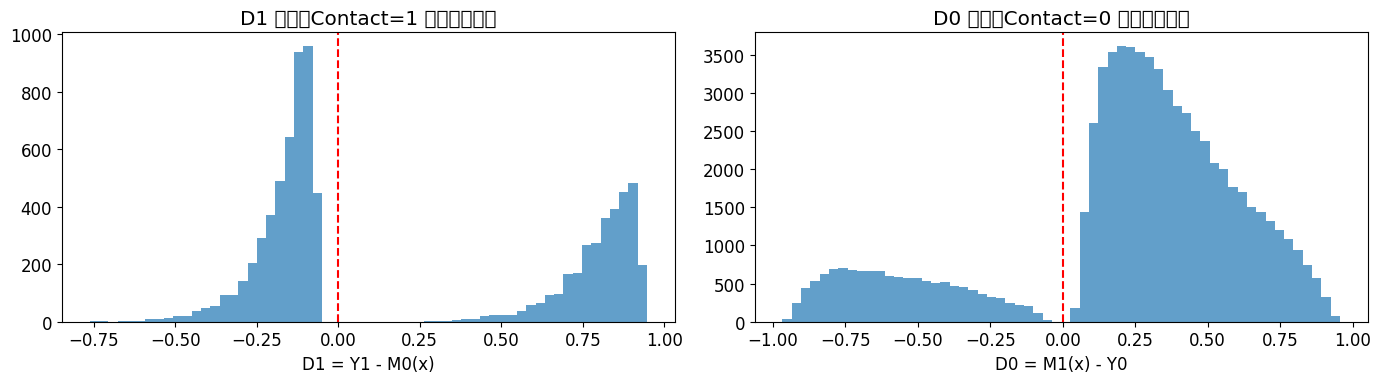

In [4]:
# ============================================================
# 3. Step 2：計算偽目標（Pseudo Outcomes）
# ============================================================
#
# Contact=1 群：D1 = 實際捐款率 - M0 預測的「沒被聯繫時」捐款率
#              D1 > 0 → 聯繫讓這個人「超預期」捐款
#              D1 < 0 → Sleeping Dog（聯繫後比預期少）
#
# Contact=0 群：D0 = M1 預測的「被聯繫時」捐款率 - 實際捐款率
#              D0 > 0 → 如果聯繫他，預期比現在多貢獻

D1 = Y1 - M0.predict_proba(X1)[:, 1]   # pseudo CATE for treated
D0 = M1.predict_proba(X0)[:, 1] - Y0   # pseudo CATE for control

print(f'D1 (Contact=1 群) 統計:')
print(f'  mean={D1.mean():.4f}, std={D1.std():.4f}')
print(f'  正值(實際>預期): {(D1>0).sum():,}, 負值(Sleeping Dog): {(D1<0).sum():,}')
print(f'\nD0 (Contact=0 群) 統計:')
print(f'  mean={D0.mean():.4f}, std={D0.std():.4f}')
print(f'  正值(聯繫有效): {(D0>0).sum():,}, 負值: {(D0<0).sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(D1, bins=60, alpha=0.7); axes[0].axvline(0, c='r', ls='--')
axes[0].set_title('D1 分布（Contact=1 群的偽目標）'); axes[0].set_xlabel('D1 = Y1 - M0(x)')
axes[1].hist(D0, bins=60, alpha=0.7); axes[1].axvline(0, c='r', ls='--')
axes[1].set_title('D0 分布（Contact=0 群的偽目標）'); axes[1].set_xlabel('D0 = M1(x) - Y0')
plt.tight_layout(); plt.show()

In [5]:
# ============================================================
# 4. Step 3 & 4：訓練 CATE 估計器 + Propensity Score
# ============================================================

# τ1：在 Contact=1 群，預測 D1（個別化 treatment effect）
tau1 = GradientBoostingRegressor(**BEST_PARAMS)
tau1.fit(X1, D1)
r2_tau1 = r2_score(D1, tau1.predict(X1))
print(f'τ1 Train R²: {r2_tau1:.4f}  (target: D1)')

# τ0：在 Contact=0 群，預測 D0
tau0 = GradientBoostingRegressor(**BEST_PARAMS)
tau0.fit(X0, D0)
r2_tau0 = r2_score(D0, tau0.predict(X0))
print(f'τ0 Train R²: {r2_tau0:.4f}  (target: D0)')

# Propensity Score：P(Contact=1 | x)，用全量 train_split
X_all_tr = preprocess(train_split, feature_cols)
W_all    = train_split['Contact'].values.astype(int)
propensity_model = GradientBoostingClassifier(**BEST_PARAMS)
propensity_model.fit(X_all_tr, W_all)
ps_auc = roc_auc_score(W_all, propensity_model.predict_proba(X_all_tr)[:, 1])
print(f'\nPropensity Score Train AUC: {ps_auc:.4f}')
print(f'  （AUC >> 0.5 代表 Contact 非隨機分配，PS 加權有意義）')

def predict_cate(X_df, tau0, tau1, propensity_model):
    """X-Learner CATE = g(x)*τ0(x) + (1-g(x))*τ1(x)"""
    g  = propensity_model.predict_proba(X_df)[:, 1]   # P(Contact=1|x)
    t0 = tau0.predict(X_df)
    t1 = tau1.predict(X_df)
    return g * t0 + (1 - g) * t1

cate_val = predict_cate(X_val, tau0, tau1, propensity_model)
print(f'\n驗證集 CATE 統計:')
print(f'  mean={cate_val.mean():.4f}, std={cate_val.std():.4f}')
print(f'  CATE > 0: {(cate_val>0).sum():,}, CATE < 0 (Sleeping Dogs): {(cate_val<0).sum():,}')

τ1 Train R²: 0.3139  (target: D1)
τ0 Train R²: 0.2450  (target: D0)

Propensity Score Train AUC: 0.7210
  （AUC >> 0.5 代表 Contact 非隨機分配，PS 加權有意義）

驗證集 CATE 統計:
  mean=0.2192, std=0.2050
  CATE > 0: 17,241, CATE < 0 (Sleeping Dogs): 2,759


X-Learner 驗證集 Uplift 策略:
  聯繫人數: 14,878, Surplus: $147,240
  真實最佳: 19,999 人, $173,380
  策略效率: 84.9%

比較:
  GBM Single Model: 70.3%
  T-Learner:        64.5%
  X-Learner:        84.9%


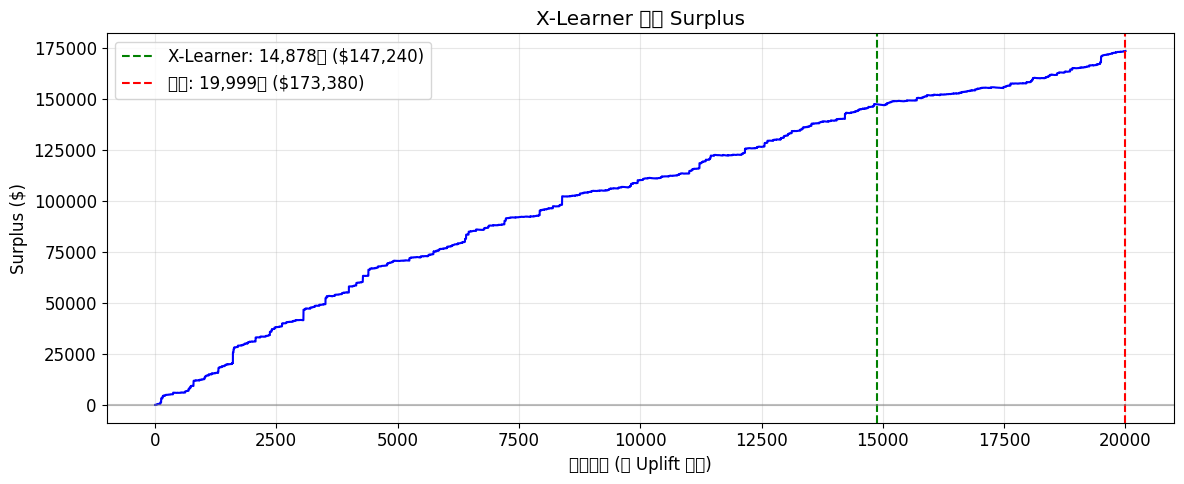

In [6]:
# ============================================================
# 5. Uplift 驗證
# ============================================================

COST_SCHEDULE = [(60_000, 5), (np.inf, 25)]

def calc_total_cost(n, schedule):
    total, remaining, prev = 0, n, 0
    for limit, cost in schedule:
        tier = min(remaining, limit - prev)
        if tier <= 0: break
        total += tier * cost
        remaining -= tier; prev = limit
    return total

def get_marginal_cost(rank, schedule):
    for limit, cost in schedule:
        if rank <= limit: return cost
    return schedule[-1][1]

# X-Learner 的 CATE 直接當 Uplift（機率單位）
# 需要轉換成金額單位：CATE_prob × E[amount|gave]
donor_mean_amt = train.loc[train['AmtThisYear'] > 0, 'AmtThisYear'].mean()
uplift_val = cate_val * donor_mean_amt   # 轉換為 $ Uplift

vdf = pd.DataFrame({
    'uplift': uplift_val, 'actual_amt': Y_amt_val
}).sort_values('uplift', ascending=False).reset_index(drop=True)

vdf['rank']          = range(1, len(vdf)+1)
vdf['marginal_cost'] = vdf['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))
vdf['cum_donation']  = vdf['actual_amt'].cumsum()
vdf['cum_cost']      = vdf['rank'].apply(lambda n: calc_total_cost(n, COST_SCHEDULE))
vdf['cum_surplus']   = vdf['cum_donation'] - vdf['cum_cost']

our_n        = (vdf['uplift'] > vdf['marginal_cost']).sum()
our_surplus  = vdf.loc[our_n-1, 'cum_surplus'] if our_n > 0 else 0
best_n       = vdf['cum_surplus'].idxmax() + 1
best_surplus = vdf['cum_surplus'].max()

print(f'X-Learner 驗證集 Uplift 策略:')
print(f'  聯繫人數: {our_n:,}, Surplus: ${our_surplus:,.0f}')
print(f'  真實最佳: {best_n:,} 人, ${best_surplus:,.0f}')
print(f'  策略效率: {our_surplus/best_surplus:.1%}')
print(f'\n比較:')
print(f'  GBM Single Model: 70.3%')
print(f'  T-Learner:        64.5%')
print(f'  X-Learner:        {our_surplus/best_surplus:.1%}')

# Surplus 曲線
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(vdf['rank'], vdf['cum_surplus'], 'b-', lw=1.5)
ax.axvline(our_n,  color='green', ls='--', label=f'X-Learner: {our_n:,}人 (${our_surplus:,.0f})')
ax.axvline(best_n, color='red',   ls='--', label=f'最佳: {best_n:,}人 (${best_surplus:,.0f})')
ax.axhline(0, color='gray', alpha=0.5)
ax.set_xlabel('聯繫人數 (按 Uplift 降序)'); ax.set_ylabel('Surplus ($)')
ax.set_title('X-Learner 累積 Surplus'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [7]:
# ============================================================
# 6. 全量重訓練 → SCOREDATA 評分
# ============================================================

full_tr0 = train[train['Contact'] == 0].reset_index(drop=True)
full_tr1 = train[train['Contact'] == 1].reset_index(drop=True)
X_full_tr0 = preprocess(full_tr0, feature_cols)
X_full_tr1 = preprocess(full_tr1, feature_cols)
Y_full_0   = full_tr0['GaveThisYear'].astype(int).values
Y_full_1   = full_tr1['GaveThisYear'].astype(int).values

# M0, M1 全量
M0_f = GradientBoostingClassifier(**BEST_PARAMS); M0_f.fit(X_full_tr0, Y_full_0)
M1_f = GradientBoostingClassifier(**BEST_PARAMS); M1_f.fit(X_full_tr1, Y_full_1)

# Pseudo outcomes 全量
D1_f = Y_full_1 - M0_f.predict_proba(X_full_tr1)[:, 1]
D0_f = M1_f.predict_proba(X_full_tr0)[:, 1] - Y_full_0

# τ0, τ1 全量
tau1_f = GradientBoostingRegressor(**BEST_PARAMS); tau1_f.fit(X_full_tr1, D1_f)
tau0_f = GradientBoostingRegressor(**BEST_PARAMS); tau0_f.fit(X_full_tr0, D0_f)

# Propensity Score 全量
X_all_full = preprocess(train, feature_cols)
W_all_full = train['Contact'].values.astype(int)
ps_f = GradientBoostingClassifier(**BEST_PARAMS); ps_f.fit(X_all_full, W_all_full)

print('全量模型訓練完成（M0, M1, τ0, τ1, Propensity）')

score_c  = load_and_clean('data/表格_FUNDRAISE_R2_CONTACT_SCOREDATA.csv')
score_nc = load_and_clean('data/表格_FUNDRAISE_R2_NOCONTACT_SCOREDATA.csv')
score_ids = score_c['ID'].copy()
Xs = preprocess(score_c, feature_cols)   # 兩份 SCOREDATA 特徵相同（Contact 已被 drop）

cate_score = predict_cate(Xs, tau0_f, tau1_f, ps_f)
uplift_score = cate_score * donor_mean_amt

print(f'CATE 統計: mean={cate_score.mean():.4f}, 正值={( cate_score>0).sum():,}')

全量模型訓練完成（M0, M1, τ0, τ1, Propensity）
CATE 統計: mean=0.2052, 正值=84,445


In [8]:
# ============================================================
# 7. 四象限分類 & 匯出
# ============================================================

score_df = pd.DataFrame({
    'ID': score_ids.values, 'CATE': cate_score, 'uplift_dollar': uplift_score
}).sort_values('uplift_dollar', ascending=False).reset_index(drop=True)

score_df['rank']          = range(1, len(score_df)+1)
score_df['marginal_cost'] = score_df['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))

# X-Learner 只用 Uplift（無 EV_nocontact），四象限簡化為：
# Persuadable: uplift > cost
# Sleeping Dog: CATE < 0
# Lost Cause: 其餘
def classify(row):
    if row['uplift_dollar'] > row['marginal_cost']:  return 'Persuadable'
    elif row['CATE'] < 0:                            return 'Sleeping Dog'
    else:                                             return 'Lost Cause'

score_df['quadrant'] = score_df.apply(classify, axis=1)
contact    = score_df[score_df['quadrant'] == 'Persuadable']
n_contact  = len(contact)
total_cost = calc_total_cost(n_contact, COST_SCHEDULE)

print('四象限分布:')
print(score_df['quadrant'].value_counts())
print(f'\n聯繫: {n_contact:,} 人, 預估成本 ${total_cost:,.0f}')
print(f'比較 GBM Optuna: 52,243 人')

import os; os.makedirs('output', exist_ok=True)
output_path = 'output/level2_xlearner_contact_list.csv'
contact[['ID']].to_csv(output_path, index=False)
print(f'\n已匯出 → {output_path}')

四象限分布:
quadrant
Persuadable     60000
Lost Cause      24445
Sleeping Dog    15555
Name: count, dtype: int64

聯繫: 60,000 人, 預估成本 $300,000
比較 GBM Optuna: 52,243 人

已匯出 → output/level2_xlearner_contact_list.csv


In [9]:
# ============================================================
# [實驗] 人均金額個人化版本
# ============================================================
# 原版：uplift_dollar = CATE_prob × $65.21（所有人用同一均值）
# 改版：uplift_dollar = CATE_prob × personal_expected_amt
#        personal_expected_amt = AmtLastYear（若有歷史記錄）
#                               或 AvgGift = TotalGift/Frequency（次選）
#                               或 $65.21（fallback）

score_raw_c = load_and_clean('data/表格_FUNDRAISE_R2_CONTACT_SCOREDATA.csv')

def personal_expected_amount(df, fallback=65.21):
    freq = df['Frequency'].clip(lower=1)
    avg_gift = df['TotalGift'] / freq
    amt = df['AmtLastYear'].copy()
    amt = amt.where(amt > 0, avg_gift)      # 無去年記錄 → 用歷史平均
    amt = amt.where(amt > 0, fallback)       # 還是 0 → 用全體均值
    return amt.values

personal_amt = personal_expected_amount(score_raw_c)
uplift_personal = cate_score * personal_amt

# 驗證集也算一次（對比）
val_raw = val_split.copy()
val_personal_amt = personal_expected_amount(val_split)
uplift_val_personal = cate_val * val_personal_amt

vdf_p = pd.DataFrame({
    'uplift': uplift_val_personal, 'actual_amt': Y_amt_val
}).sort_values('uplift', ascending=False).reset_index(drop=True)
vdf_p['rank']          = range(1, len(vdf_p)+1)
vdf_p['marginal_cost'] = vdf_p['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))
vdf_p['cum_donation']  = vdf_p['actual_amt'].cumsum()
vdf_p['cum_cost']      = vdf_p['rank'].apply(lambda n: calc_total_cost(n, COST_SCHEDULE))
vdf_p['cum_surplus']   = vdf_p['cum_donation'] - vdf_p['cum_cost']

our_n_p       = (vdf_p['uplift'] > vdf_p['marginal_cost']).sum()
our_surplus_p = vdf_p.loc[our_n_p-1, 'cum_surplus'] if our_n_p > 0 else 0
best_surplus_p = vdf_p['cum_surplus'].max()

print(f'人均金額個人化版本 vs 固定均值版本:')
print(f'  固定均值 ($65.21): 效率={our_surplus/best_surplus:.1%}, 聯繫={our_n:,} 人')
print(f'  個人化金額:        效率={our_surplus_p/best_surplus_p:.1%}, 聯繫={our_n_p:,} 人')
print(f'\n個人化金額統計:')
print(f'  mean=${personal_amt.mean():.2f}, median=${np.median(personal_amt):.2f}, max=${personal_amt.max():.2f}')

# SCOREDATA 個人化版本
score_df_p = pd.DataFrame({
    'ID': score_ids.values, 'CATE': cate_score, 'uplift_dollar': uplift_personal
}).sort_values('uplift_dollar', ascending=False).reset_index(drop=True)
score_df_p['rank']          = range(1, len(score_df_p)+1)
score_df_p['marginal_cost'] = score_df_p['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))

def classify_p(row):
    if row['uplift_dollar'] > row['marginal_cost']:  return 'Persuadable'
    elif row['CATE'] < 0:                            return 'Sleeping Dog'
    else:                                             return 'Lost Cause'

score_df_p['quadrant'] = score_df_p.apply(classify_p, axis=1)
contact_p   = score_df_p[score_df_p['quadrant'] == 'Persuadable']
n_contact_p = len(contact_p)
cost_p      = calc_total_cost(n_contact_p, COST_SCHEDULE)

print(f'\nSCOREDATA 個人化版本:')
print(score_df_p['quadrant'].value_counts())
print(f'聯繫: {n_contact_p:,} 人, 預估成本 ${cost_p:,.0f}')
print(f'比較原版 X-Learner: 60,000 人')

contact_p[['ID']].to_csv('output/level2_xlearner_personal_contact_list.csv', index=False)
print(f'\n已匯出 → output/level2_xlearner_personal_contact_list.csv')

人均金額個人化版本 vs 固定均值版本:
  固定均值 ($65.21): 效率=84.9%, 聯繫=14,878 人
  個人化金額:        效率=66.4%, 聯繫=10,428 人

個人化金額統計:
  mean=$60.57, median=$26.12, max=$10000.00

SCOREDATA 個人化版本:
quadrant
Persuadable     49567
Lost Cause      34878
Sleeping Dog    15555
Name: count, dtype: int64
聯繫: 49,567 人, 預估成本 $247,835
比較原版 X-Learner: 60,000 人

已匯出 → output/level2_xlearner_personal_contact_list.csv


In [10]:
# ============================================================
# [實驗] 截尾均值（Winsorized Mean）：掃描最佳截尾點
# ============================================================
# CATE 只影響排序的尺度，切點由 uplift_dollar > 成本 決定
# 截尾均值 = 去掉 top X% 的捐款者後取均值
# → 截尾點越高（越保守），選出的名單越小

import pandas as pd, numpy as np

train_raw = pd.read_csv('data/表格_FUNDRAISE_R2_TRAIN.csv', encoding='utf-8-sig', low_memory=False)
train_raw.columns = train_raw.columns.str.strip().str.strip('"')
train_raw['AmtThisYear'] = pd.to_numeric(train_raw['AmtThisYear'], errors='coerce')
donors = train_raw[train_raw['AmtThisYear'] > 0]['AmtThisYear']

# 掃描各截尾點的均值和對應門檻
print(f'{"截尾點":<8} {"均值":>8} {"CATE門檻":>10} {"CATE門檻詞義":>20}')
print("-" * 55)
for p in [None, 99, 97, 95, 90, 85, 80, 75]:
    if p is None:
        mean = donors.mean()
        label = "不截尾（原版）"
    else:
        cutoff = donors.quantile(p/100)
        mean = donors[donors <= cutoff].mean()
        label = f"去掉前{100-p}%（>${cutoff:.0f}）"
    threshold = 5 / mean
    print(f"  p{p if p else '--':<4}  ${mean:>7.2f}   >{threshold:.4f}   {label}")

# 在驗證集上比較各截尾均值的 Surplus
print(f'\n驗證集比較（cate_val 來自本 session 的 X-Learner）:')
print(f'{"截尾點":<8} {"均值":>8} {"聯繫人數":>10} {"Surplus":>12} {"效率":>8}')
print("-" * 55)

for p in [None, 99, 97, 95, 90, 85, 80]:
    if p is None:
        amt = donors.mean()
    else:
        cutoff = donors.quantile(p/100)
        amt = donors[donors <= cutoff].mean()

    uplift = cate_val * amt

    vdf_t = pd.DataFrame({'uplift': uplift, 'actual_amt': Y_amt_val}) \
              .sort_values('uplift', ascending=False).reset_index(drop=True)
    vdf_t['rank']          = range(1, len(vdf_t)+1)
    vdf_t['marginal_cost'] = vdf_t['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))
    vdf_t['cum_donation']  = vdf_t['actual_amt'].cumsum()
    vdf_t['cum_cost']      = vdf_t['rank'].apply(lambda n: calc_total_cost(n, COST_SCHEDULE))
    vdf_t['cum_surplus']   = vdf_t['cum_donation'] - vdf_t['cum_cost']

    n = (vdf_t['uplift'] > vdf_t['marginal_cost']).sum()
    s = vdf_t.loc[n-1, 'cum_surplus'] if n > 0 else 0
    best = vdf_t['cum_surplus'].max()
    eff = s / best if best > 0 else 0

    tag = " ← 目前" if p is None else ""
    print(f"  p{p if p else '--':<4}  ${amt:>7.2f}  {n:>9,}  ${s:>10,.0f}  {eff:>7.1%}{tag}")

截尾點            均值     CATE門檻             CATE門檻詞義
-------------------------------------------------------
  p--    $  67.25   >0.0743   不截尾（原版）
  p99    $  49.25   >0.1015   去掉前1%（>$750）
  p97    $  39.69   >0.1260   去掉前3%（>$300）
  p95    $  36.46   >0.1371   去掉前5%（>$200）
  p90    $  31.03   >0.1611   去掉前10%（>$100）
  p85    $  27.27   >0.1834   去掉前15%（>$75）
  p80    $  24.43   >0.2046   去掉前20%（>$50）
  p75    $  24.43   >0.2046   去掉前25%（>$50）

驗證集比較（cate_val 來自本 session 的 X-Learner）:
截尾點            均值       聯繫人數      Surplus       效率
-------------------------------------------------------
  p--    $  67.25     14,878  $   147,240    84.9% ← 目前
  p99    $  49.25     13,910  $   139,040    80.2%
  p97    $  39.69     12,973  $   131,750    76.0%
  p95    $  36.46     12,537  $   126,520    73.0%
  p90    $  31.03     11,640  $   122,355    70.6%
  p85    $  27.27     10,776  $   112,685    65.0%
  p80    $  24.43      9,995  $   110,125    63.5%
